In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('customer_churn.csv', na_values=['?', -999])

In [2]:
df.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,NaN,...,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,NaN,CID21329,Gift Vouchers/Coupons,Desktop,...,306.34,12838.38,10,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,...,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,...,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,...,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1


In [3]:
df.tail()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
36987,46,F,6F51HFO,NaN,Basic Membership,21-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Desktop,...,-650.682758,27277.68,6,639.510000,No,Yes,Yes,No Information Available,No reason specified,1
36988,29,F,21KSM8Y,Town,Basic Membership,27-06-2016,No,xxxxxxxx,Without Offers,Smartphone,...,-638.123421,11069.71,28,527.990000,Yes,No,No,Not Applicable,Poor Customer Service,1
36989,23,F,XK1IM9H,NaN,Basic Membership,11-09-2016,Yes,CID3838,Gift Vouchers/Coupons,Desktop,...,154.940000,38127.56,Error,680.470000,No,Yes,Yes,Unsolved,Poor Website,1
36990,53,M,K6VTP1Z,Village,Platinum Membership,15-06-2017,No,xxxxxxxx,Gift Vouchers/Coupons,Smartphone,...,482.610000,2378.86,20,197.264414,Yes,Yes,No,Not Applicable,No reason specified,0
36991,35,M,LBX0GLR,Town,Silver Membership,23-10-2015,No,xxxxxxxx,Gift Vouchers/Coupons,Desktop,...,79.180000,2189.68,Error,719.970000,Yes,No,No,Not Applicable,Quality Customer Care,0


In [4]:
df.isna().sum()

age                                0
gender                             0
security_no                        0
region_category                 5428
membership_category                0
joining_date                       0
joined_through_referral         5438
referral_id                        0
preferred_offer_types            288
medium_of_operation             5393
internet_option                    0
last_visit_time                    0
days_since_last_login           1999
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                3443
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
dtype: int64

In [5]:
df.isna().any(axis=1).sum()

np.int64(17420)

<Axes: >

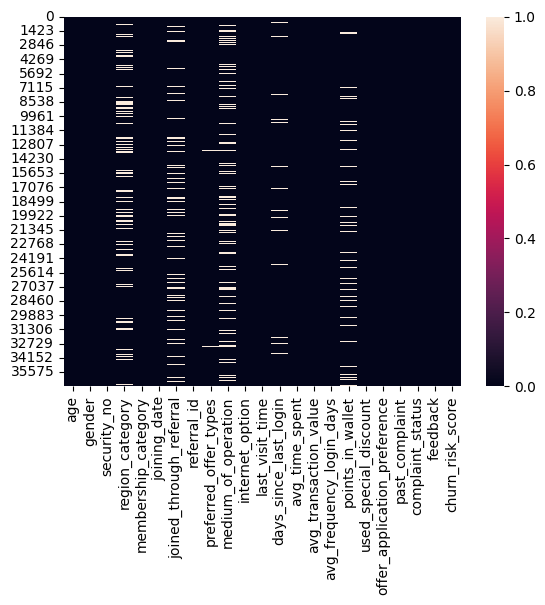

In [6]:
import seaborn as sns

sns.heatmap(df.isna())

In [7]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
age,1.000000,-0.002017,0.001531,-0.000473,0.000205,0.006124
days_since_last_login,-0.002017,1.000000,-0.090335,-0.017037,0.000364,0.016773
avg_time_spent,0.001531,-0.090335,1.000000,0.020888,-0.000648,-0.014263
avg_transaction_value,-0.000473,-0.017037,0.020888,1.000000,0.087950,-0.218012
points_in_wallet,0.000205,0.000364,-0.000648,0.087950,1.000000,-0.307439
churn_risk_score,0.006124,0.016773,-0.014263,-0.218012,-0.307439,1.000000


In [8]:
len(df.security_no.unique())

36992

In [9]:
df.preferred_offer_types.unique()

array(['Gift Vouchers/Coupons', 'Credit/Debit Card Offers',
       'Without Offers', nan], dtype=object)

In [10]:
df['joined_through_referral'] = df.apply(lambda x: 'No' if x['referral_id'] == 'xxxxxxxx' else (np.nan if x['referral_id'] == 'No referral' else 'Yes'), axis=1)

In [11]:
df.rename(columns={'security_no':'customer_id'}, inplace=True)

In [12]:
df.columns

Index(['age', 'gender', 'customer_id', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='object')

In [13]:
df['joining_date'] = pd.to_datetime(df['joining_date'])

/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_18233/313696224.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['joining_date'] = pd.to_datetime(df['joining_date'])


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df.loc[df['medium_of_operation'].str.contains(r'\?', na=False), 'medium_of_operation'] = np.nan

train_df = df[df['medium_of_operation'].notna()].copy()
test_df = df[df['medium_of_operation'].isna()].copy()

encoder = LabelEncoder()
train_df['medium_of_operation_encoded'] = encoder.fit_transform(train_df['medium_of_operation'])

datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

for col in datetime_cols:
    train_df[col] = train_df[col].astype('int64') // 10**9
    test_df[col] = test_df[col].astype('int64') // 10**9 

categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('medium_of_operation')

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    
    label_encoders[col] = le

    test_df[col] = test_df[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

clf = RandomForestClassifier(random_state=42)
clf.fit(train_df.drop(columns=['medium_of_operation', 'medium_of_operation_encoded']), 
        train_df['medium_of_operation_encoded'])

test_df['medium_of_operation_encoded'] = clf.predict(test_df.drop(columns=['medium_of_operation']))

test_df['medium_of_operation'] = encoder.inverse_transform(test_df['medium_of_operation_encoded'])

df.loc[test_df.index, 'medium_of_operation'] = test_df['medium_of_operation']

if 'medium_of_operation_encoded' in df.columns:
    df.drop(columns=['medium_of_operation_encoded'], inplace=True)

In [15]:
df = df[df['days_since_last_login'] >= 0]


In [16]:
df.drop(df[df['avg_time_spent'] < 0].index, inplace=True)
df.drop(df[df['points_in_wallet'] == 'Error'].index, inplace=True)
df['points_in_wallet'] = pd.to_numeric(df['points_in_wallet'], errors='coerce')
df.drop(df[df['points_in_wallet'] < 0].index, inplace=True)
df.drop(df[df['avg_frequency_login_days'] == 'Error'].index, inplace=True)
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')
df.drop(df[df['avg_frequency_login_days'] < 0].index, inplace=True)


In [17]:
df['region_category'] = df['region_category'].fillna(
    df.groupby('membership_category')['region_category'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
)


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Step 1: Create a missing value mask BEFORE encoding
missing_mask = df['preferred_offer_types'].isna()

# Step 2: Copy dataframe and encode
df_temp = df.copy()
features = ['referral_id', 'medium_of_operation', 'internet_option']
target = 'preferred_offer_types'

encoders = {}
for col in features + [target]:
    le = LabelEncoder()
    df_temp[col] = df_temp[col].astype(str)
    df_temp[col] = le.fit_transform(df_temp[col])
    encoders[col] = le

# Step 3: Split based on original missing_mask
train_data = df_temp[~missing_mask]
test_data = df_temp[missing_mask]

# Step 4: Train & predict
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(train_data[features], train_data[target])

preds = clf.predict(test_data[features])
preds_decoded = encoders[target].inverse_transform(preds)

# Step 5: Fill the missing values
df.loc[missing_mask, 'preferred_offer_types'] = preds_decoded



In [19]:
df.dropna(axis=1, how='any', inplace=True)

In [20]:
df.shape

(29488, 21)

<Axes: xlabel='churn_risk_score', ylabel='count'>

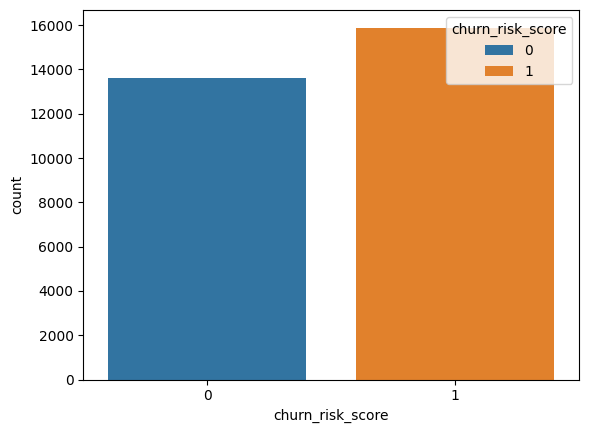

In [21]:
sns.countplot(x='churn_risk_score', data=df, hue='churn_risk_score')

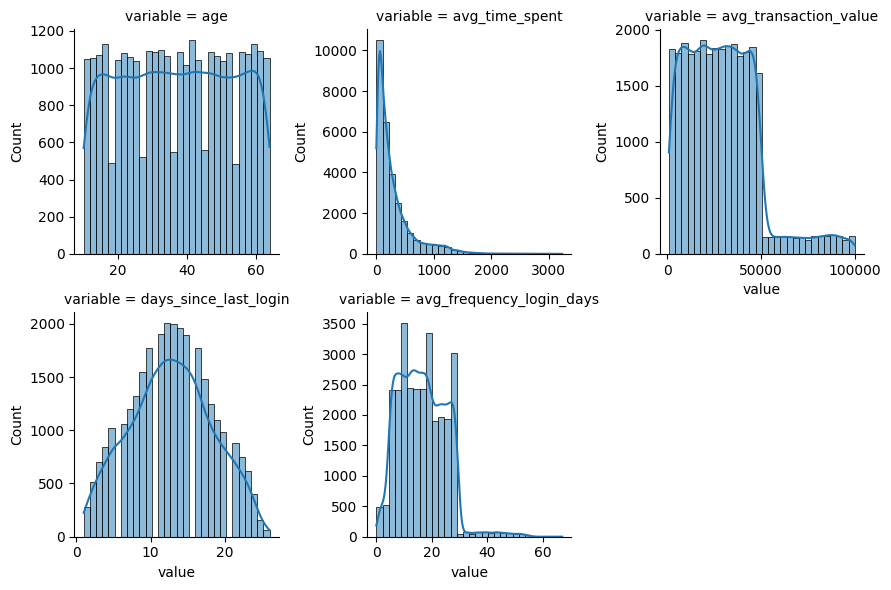

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ['age', 'avg_time_spent', 'avg_transaction_value', 'days_since_last_login', 'avg_frequency_login_days']

g = sns.FacetGrid(pd.melt(df[numerical_columns]), col="variable", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True, bins=30)

plt.show()

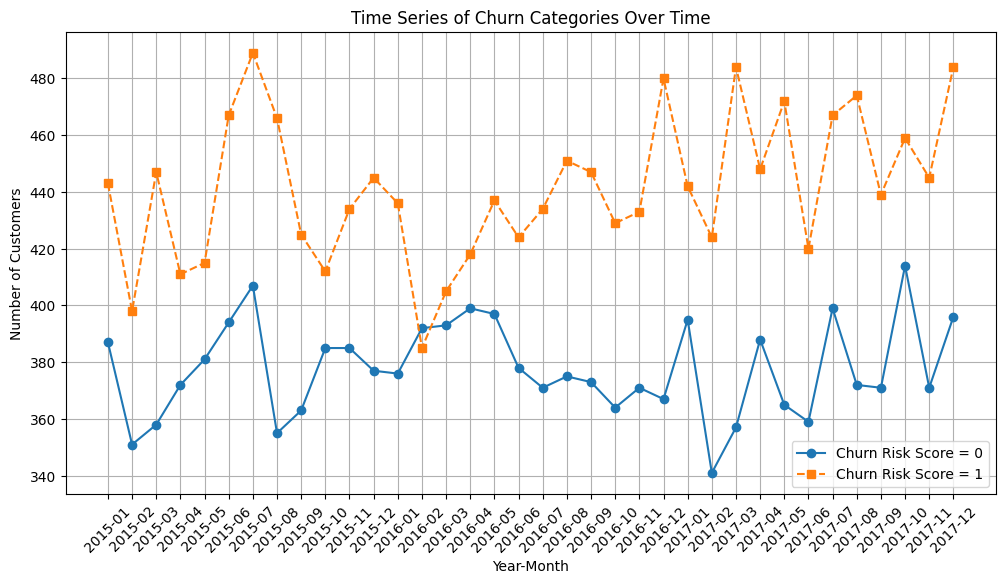

In [23]:
df['year_month'] = df['joining_date'].dt.to_period('M')

df_churn_counts = df.groupby(['year_month', 'churn_risk_score']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
plt.plot(df_churn_counts.index.astype(str), df_churn_counts[0], marker='o', linestyle='-', label='Churn Risk Score = 0')
plt.plot(df_churn_counts.index.astype(str), df_churn_counts[1], marker='s', linestyle='--', label='Churn Risk Score = 1')

plt.xlabel("Year-Month")
plt.ylabel("Number of Customers")
plt.title("Time Series of Churn Categories Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

/Users/manpreetmahal/Desktop/CustomerChurn/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


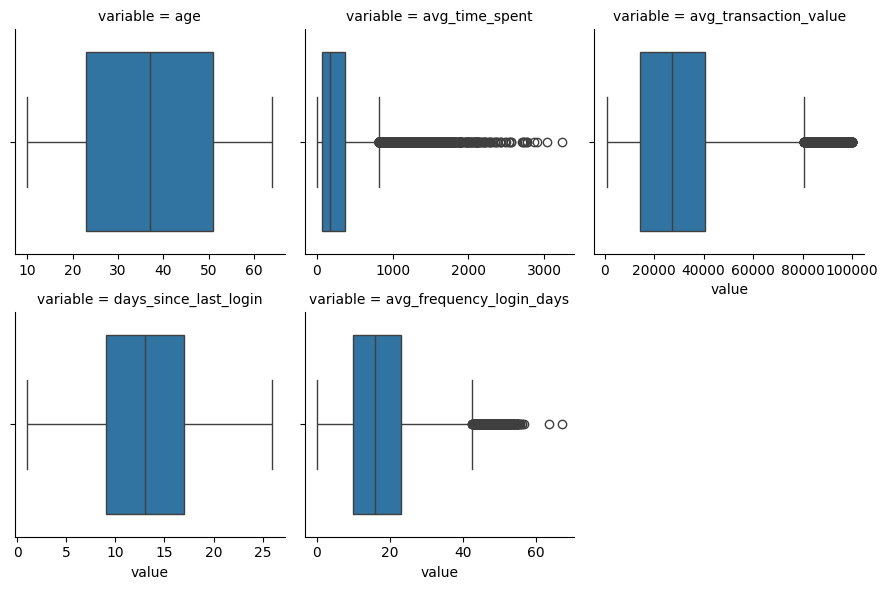

In [24]:
numerical_columns = ['age', 'avg_time_spent', 'avg_transaction_value', 'days_since_last_login', 'avg_transaction_value', 'avg_frequency_login_days']

g = sns.FacetGrid(pd.melt(df[numerical_columns]), col="variable", col_wrap=3, sharex=False, sharey=False)
g.map(sns.boxplot, "value")

plt.show()


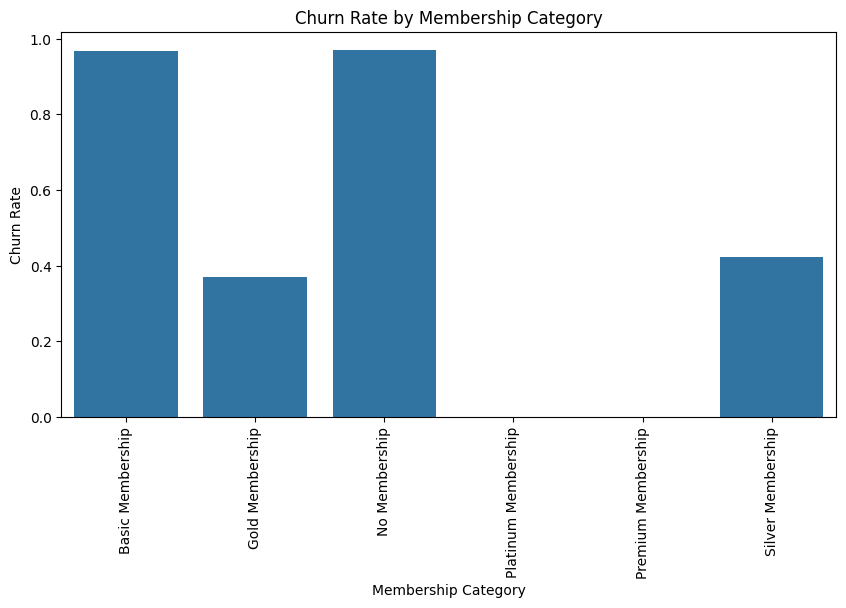

In [25]:
plt.figure(figsize=(10, 5))
churn_rate_by_membership = df.groupby("membership_category")["churn_risk_score"].mean()
sns.barplot(x=churn_rate_by_membership.index, y=churn_rate_by_membership.values)
plt.xlabel("Membership Category")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Membership Category")
plt.xticks(rotation=90)
plt.show()

- Higher-tier memberships (Gold, Silver) tend to retain customers better.
- Lower-tier memberships (Basic, No Membership) have extremely high churn, meaning they may need incentives to stay (discounts, better benefits, engagement strategies).
- Missing data for Platinum/Premium should be checked to confirm if it’s truly zero churn or a data issue.

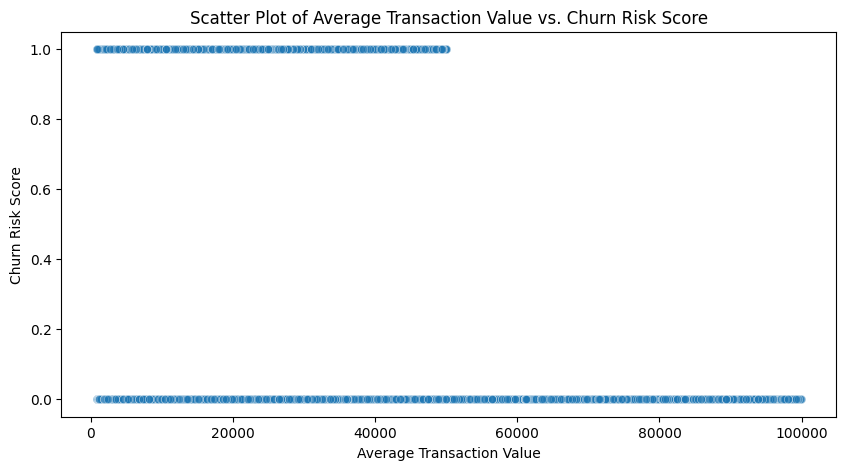

In [26]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="avg_transaction_value", y="churn_risk_score", alpha=0.5)
plt.xlabel("Average Transaction Value")
plt.ylabel("Churn Risk Score")
plt.title("Scatter Plot of Average Transaction Value vs. Churn Risk Score")
plt.show()

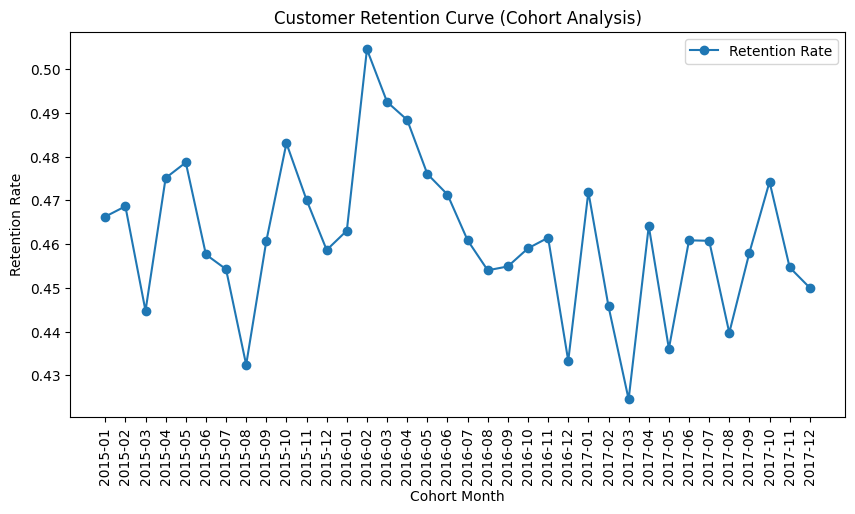

In [27]:
df['cohort_month'] = df['joining_date'].dt.to_period('M')
cohort_counts = df.groupby(['cohort_month', 'churn_risk_score']).size().unstack(fill_value=0)
cohort_counts['total'] = cohort_counts.sum(axis=1)
cohort_counts['retention_rate'] = cohort_counts[0] / cohort_counts['total']

plt.figure(figsize=(10, 5))
plt.plot(cohort_counts.index.astype(str), cohort_counts['retention_rate'], marker='o', linestyle='-', label="Retention Rate")
plt.xlabel("Cohort Month")
plt.ylabel("Retention Rate")
plt.title("Customer Retention Curve (Cohort Analysis)")
plt.xticks(rotation=90)
plt.legend()
plt.show()


In [28]:
def full_diagnostic(df,class_col,cols_to_exclude):
  import seaborn as sns
  import numpy as np
  cols=df.select_dtypes(include=np.number).columns.tolist()
  X=df[cols]
  X = X[X.columns.difference(cols_to_exclude)]
  X = X[X.columns.difference([class_col])]
  sns.pairplot(df,hue = class_col)

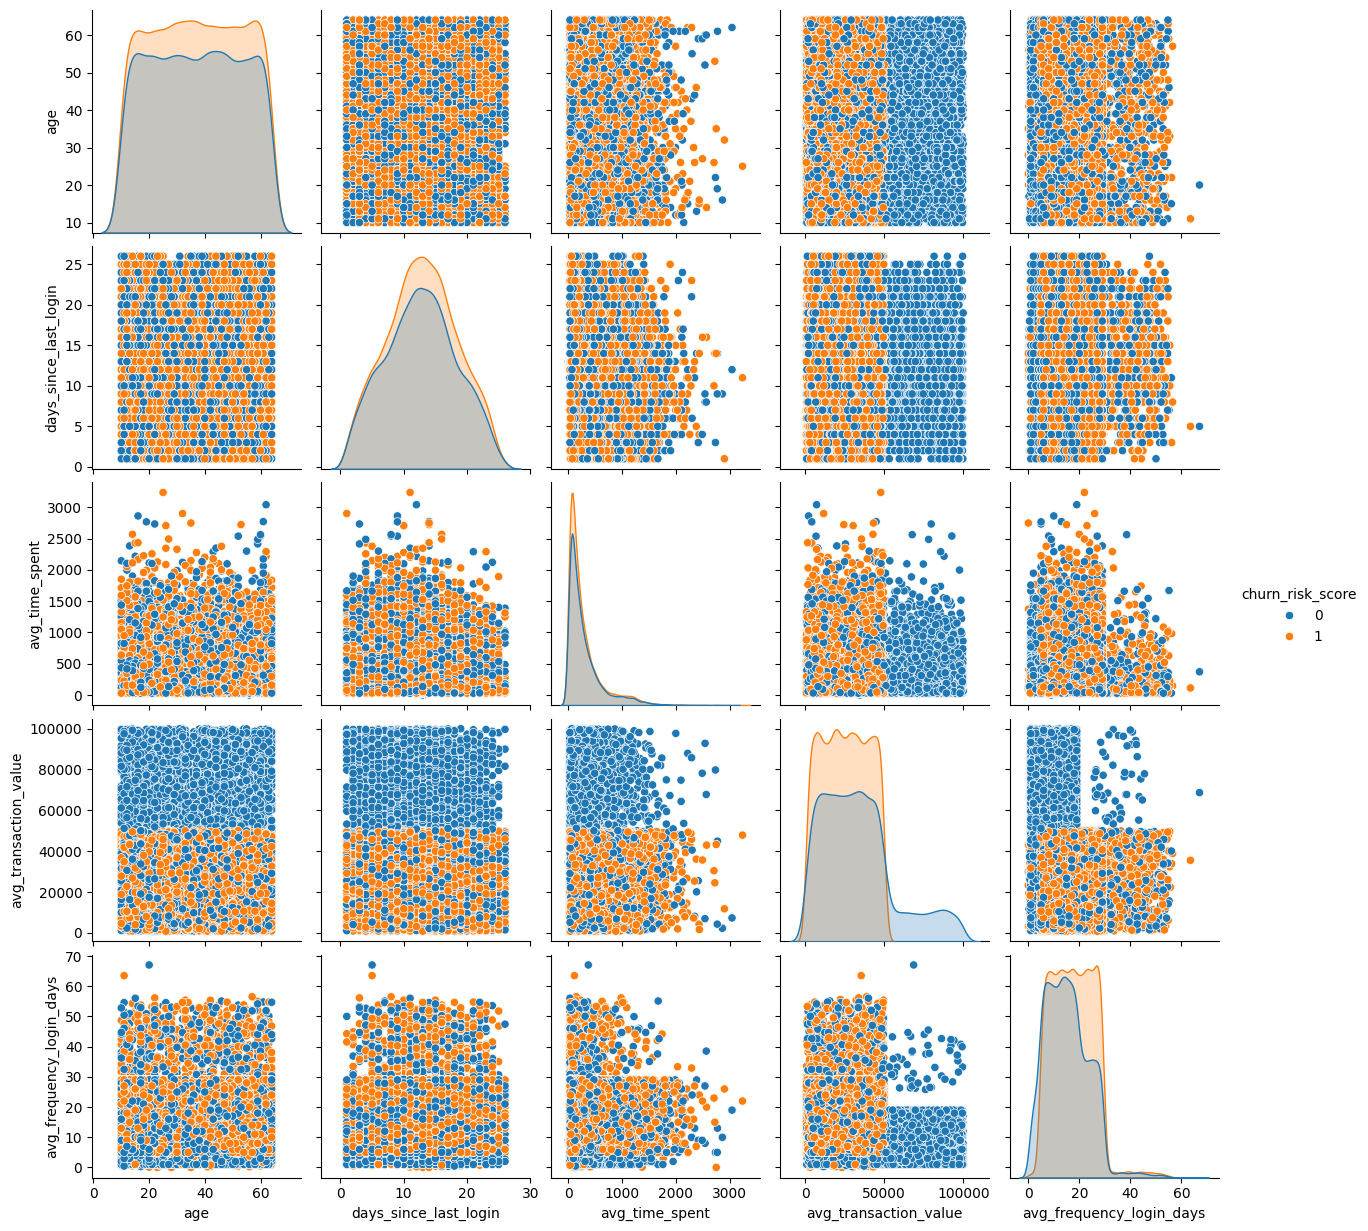

In [29]:
full_diagnostic(df,class_col = 'churn_risk_score',cols_to_exclude=['customer_id','joining_date'])

In [30]:
# function for creating plots for selective columns only
def selected_diagnotic(df,class_col,cols_to_eval):
  import seaborn as sns
  cols_to_eval.append(class_col) 
  X = df[cols_to_eval] # only selective columns
  sns.pairplot(X,hue = class_col) # plot

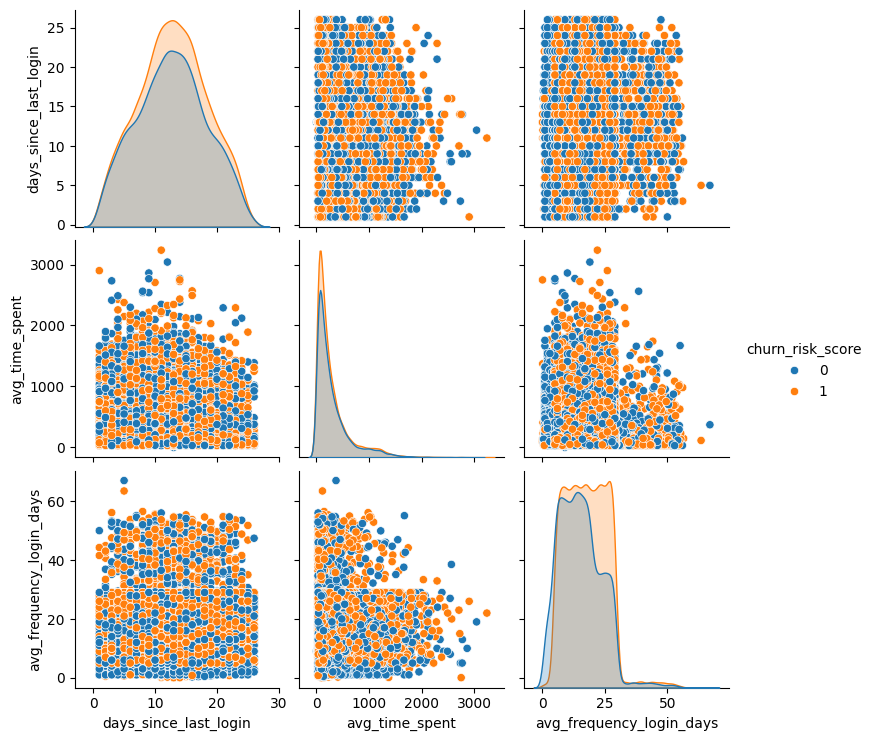

In [31]:
selected_diagnotic(df,class_col = 'churn_risk_score',cols_to_eval = ['days_since_last_login', 'avg_time_spent', 'avg_frequency_login_days'])

## Running Logistic Regression

In [32]:
def logistic_regression(df, class_col, cols_to_exclude, scale=False):
    import statsmodels.api as sm
    import numpy as np
    from sklearn.preprocessing import StandardScaler, OrdinalEncoder

    # Separate numerical and categorical features
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Remove target and excluded columns from both
    for col in [class_col] + cols_to_exclude:
        if col in numeric_cols:
            numeric_cols.remove(col)
        if col in cat_cols:
            cat_cols.remove(col)

    # Ordinal Encoding for categorical features
    if cat_cols:
        encoder = OrdinalEncoder()
        df[cat_cols] = encoder.fit_transform(df[cat_cols])

    # Combine selected features
    feature_cols = numeric_cols + cat_cols
    X = df[feature_cols]

    # Scale if required
    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    y = df[class_col]

    # Add constant manually (statsmodels needs this)
    X = sm.add_constant(X)

    logit_model = sm.Logit(y, X)
    result = logit_model.fit()
    print(result.summary2())


In [33]:
logistic_regression(df,class_col = 'churn_risk_score',cols_to_exclude=['customer_id','joining_date', 'feedback', 'year_month', 'cohort_month'], scale = False)

Optimization terminated successfully.
         Current function value: 0.552151
         Iterations 6
                               Results: Logit
Model:                  Logit                Method:               MLE       
Dependent Variable:     churn_risk_score     Pseudo R-squared:     0.200     
Date:                   2025-04-20 16:15     AIC:                  32599.6447
No. Observations:       29488                BIC:                  32748.8960
Df Model:               17                   Log-Likelihood:       -16282.   
Df Residuals:           29470                LL-Null:              -20351.   
Converged:              1.0000               LLR p-value:          0.0000    
No. Iterations:         6.0000               Scale:                1.0000    
-----------------------------------------------------------------------------
                              Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
------------------------------------------------------------------------

### Run the ML Model

In [34]:
def prepare_model(df,class_col,cols_to_exclude):
  from sklearn.model_selection import train_test_split
  import numpy as np
  cols=df.select_dtypes(include=np.number).columns.tolist() 
  X=df[cols]
  X = X[X.columns.difference([class_col])] 
  X = X[X.columns.difference(cols_to_exclude)]
  y=df[class_col]
  global X_train, X_test, y_train, y_test
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [35]:
def run_model(X_train,X_test,y_train,y_test):
  from sklearn.linear_model import LogisticRegression
  from sklearn.metrics import roc_auc_score,classification_report
  global logreg 
  logreg = LogisticRegression(random_state = 42)
  logreg.fit(X_train, y_train) 
  global y_pred 
  y_pred = logreg.predict(X_test) 
  logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
  print(classification_report(y_test, y_pred)) 
  print("The area under the curve is: %0.2f"%logit_roc_auc)
     

In [36]:
prepare_model(df,class_col = 'churn_risk_score',cols_to_exclude=['customer_id','joining_date', 'feedback', 'year_month', 'cohort_month'])

In [37]:
run_model(X_train,X_test,y_train,y_test)

              precision    recall  f1-score   support

           0       0.64      0.55      0.59      4127
           1       0.65      0.73      0.69      4720

    accuracy                           0.64      8847
   macro avg       0.64      0.64      0.64      8847
weighted avg       0.64      0.64      0.64      8847

The area under the curve is: 0.64


/Users/manpreetmahal/Desktop/CustomerChurn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
def confusion_matrix(y_test,y_pred):
  from sklearn.metrics import confusion_matrix
  confusion_matrix = confusion_matrix(y_test, y_pred)
  print(confusion_matrix)

  tn, fp, fn, tp = confusion_matrix.ravel()
  print('TN: %0.2f'% tn)
  print('TP: %0.2f'% tp)
  print('FP: %0.2f'%fp)
  print('FN: %0.2f'%fn)

In [39]:
def roc_curve (logreg,X_test,y_test):
  import matplotlib.pyplot as plt 
  from sklearn.metrics import roc_auc_score
  from sklearn.metrics import roc_curve
  logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
  fpr, tpr, thresholds = roc_curve(y_test, logreg.predict(X_test))
  #Setting the graph area
  plt.figure()
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])

  #Plotting the worst line possiple
  plt.plot([0, 1], [0, 1],'b--')

  #Plotting the logistic regression we have built
  plt.plot(fpr, tpr, color='darkorange', label='Logistic Regression (area = %0.2f)' % logit_roc_auc)

  #Adding labels and etc
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend(loc="lower right")
  plt.savefig('Log_ROC')
  plt.show()

In [40]:
prepare_model(df,class_col = 'churn_risk_score',cols_to_exclude=['customer_id','joining_date', 'feedback', 'year_month', 'cohort_month'])

In [41]:
confusion_matrix(y_test,y_pred)

[[2280 1847]
 [1294 3426]]
TN: 2280.00
TP: 3426.00
FP: 1847.00
FN: 1294.00


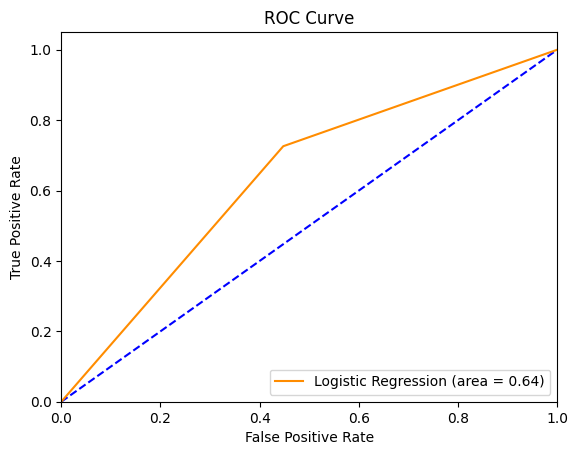

In [42]:
roc_curve (logreg,X_test,y_test)

In [43]:
df['churn_risk_score'].describe()

count    29488.000000
mean         0.538829
std          0.498498
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: churn_risk_score, dtype: float64

- The mean being around 0.54 means 54% of the customers are at rist (if 1 = risk). So your churn risk score is either 'Chill' or 'Paninc!' - no in betweens.

### Feature Selection

In [44]:
class_col = 'Churn_risk_score'
cols_to_exclude = ['customer_id','joining_date', 'feedback', 'year_month', 'cohort_month']

def var_threshold_selection(df,cols_to_exclude,class_col,threshold):
  from sklearn.feature_selection import VarianceThreshold
  import numpy as np
  from sklearn import preprocessing

  cols=df.select_dtypes(include=np.number).columns.tolist()
  X=df[cols]
  X = X[X.columns.difference(cols_to_exclude)]
  X = X[X.columns.difference([class_col])]

  scaler = preprocessing.StandardScaler().fit(X)
  X_scaled = scaler.transform(X)
  var_thr = VarianceThreshold(threshold = threshold)
  var_thr.fit(X_scaled)
  var_thr.get_support()

  global selected_cols
  selected_cols = X.columns[var_thr.get_support()]

  print("The selected features are: ")
  print(list(selected_cols))

In [45]:
var_threshold_selection(df,class_col = 'churn_risk_score',cols_to_exclude=['customer_id','joining_date', 'feedback', 'year_month', 'cohort_month'], threshold=1)

The selected features are: 
['complaint_status', 'internet_option', 'medium_of_operation', 'membership_category', 'offer_application_preference', 'region_category', 'used_special_discount']


In [46]:
df[df.columns.difference(['complaint_status', 'internet_option', 'membership_category', 'offer_application_preference', 'preferred_offer_types', 'region_category', 'used_special_discount'])].columns

Index(['age', 'avg_frequency_login_days', 'avg_time_spent',
       'avg_transaction_value', 'churn_risk_score', 'cohort_month',
       'customer_id', 'days_since_last_login', 'feedback', 'gender',
       'joining_date', 'last_visit_time', 'medium_of_operation',
       'past_complaint', 'referral_id', 'year_month'],
      dtype='object')

In [47]:
prepare_model(df,class_col = 'churn_risk_score',cols_to_exclude=['age', 'avg_frequency_login_days', 'avg_time_spent',
       'avg_transaction_value', 'churn_risk_score', 'cohort_month',
       'customer_id', 'days_since_last_login', 'feedback', 'gender',
       'joining_date', 'last_visit_time', 'medium_of_operation',
       'past_complaint', 'referral_id', 'year_month'])
run_model(X_train,X_test,y_train,y_test)

              precision    recall  f1-score   support

           0       0.83      0.72      0.77      4127
           1       0.78      0.87      0.83      4720

    accuracy                           0.80      8847
   macro avg       0.81      0.80      0.80      8847
weighted avg       0.81      0.80      0.80      8847

The area under the curve is: 0.80


In [48]:
confusion_matrix(y_test, y_pred)

[[2977 1150]
 [ 593 4127]]
TN: 2977.00
TP: 4127.00
FP: 1150.00
FN: 593.00


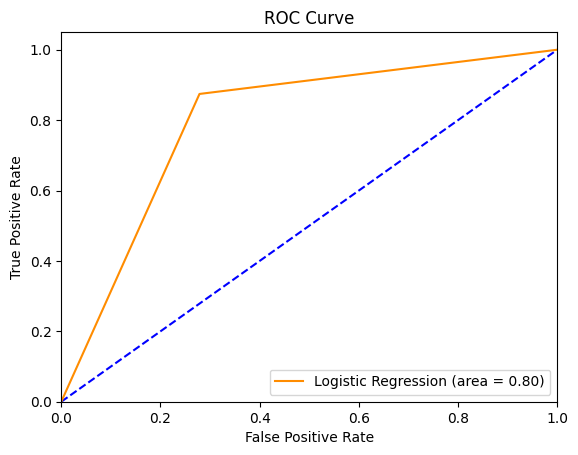

In [49]:
roc_curve (logreg,X_test,y_test)

In [50]:
# RFE for feature selection 
def rfe_selection(df,cols_to_exclude,class_col,model):
  import warnings
  warnings.filterwarnings("ignore")
  import numpy as np
  from sklearn.feature_selection import RFE

  cols=df.select_dtypes(include=np.number).columns.tolist() #finding all the numerical columns from the dataframe
  X=df[cols] #creating a dataframe only with the numerical columns
  X = X[X.columns.difference(cols_to_exclude)] #columns to exclude
  X = X[X.columns.difference([class_col])]
  y = df[class_col]

  rfe = RFE(model)
  rfe = rfe.fit(X, y) # fit the model 
  global selected_cols
  selected_cols = X.columns[rfe.support_]

  print("The selected features are: ")
  print(list(selected_cols))


In [51]:
rfe_selection(df,class_col = 'churn_risk_score',cols_to_exclude=['customer_id','joining_date', 'feedback', 'year_month', 'cohort_month'],model=logreg)

The selected features are: 
['avg_frequency_login_days', 'gender', 'medium_of_operation', 'membership_category', 'offer_application_preference', 'preferred_offer_types', 'region_category', 'used_special_discount']


In [52]:
df[df.columns.difference(['avg_frequency_login_days', 'gender', 'medium_of_operation', 'membership_category', 'offer_application_preference', 'preferred_offer_types', 'region_category', 'used_special_discount'])].columns

Index(['age', 'avg_time_spent', 'avg_transaction_value', 'churn_risk_score',
       'cohort_month', 'complaint_status', 'customer_id',
       'days_since_last_login', 'feedback', 'internet_option', 'joining_date',
       'last_visit_time', 'past_complaint', 'referral_id', 'year_month'],
      dtype='object')

In [53]:
prepare_model(df,class_col = 'churn_risk_score',cols_to_exclude=['age', 'avg_time_spent', 'avg_transaction_value', 'churn_risk_score',
       'cohort_month', 'complaint_status', 'customer_id',
       'days_since_last_login', 'feedback', 'internet_option', 'joining_date',
       'last_visit_time', 'past_complaint', 'referral_id', 'year_month'])
run_model(X_train,X_test,y_train,y_test)

              precision    recall  f1-score   support

           0       0.79      0.68      0.73      4127
           1       0.75      0.84      0.79      4720

    accuracy                           0.77      8847
   macro avg       0.77      0.76      0.76      8847
weighted avg       0.77      0.77      0.76      8847

The area under the curve is: 0.76


In [54]:
confusion_matrix(y_test, y_pred)

[[2814 1313]
 [ 763 3957]]
TN: 2814.00
TP: 3957.00
FP: 1313.00
FN: 763.00


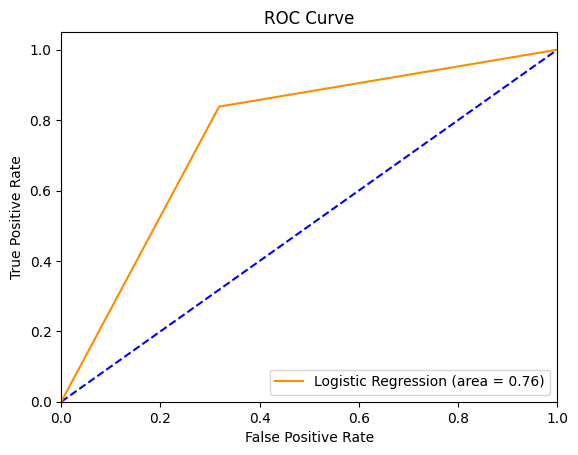

In [55]:
roc_curve (logreg,X_test,y_test)

### Decision Trees

#### Measure of Impurity

- it allows us to identify how clean a node is.
- ways to measure of impurity is using Gini Index:
    - it is 1 - the squared frequentist probability of each class.
    - 0: perfect equality
    - 1: perfect inequality

#### Steps to Implement Gini Index:

- Calculate the Gini Index of the Node and each leaf.
- Calculate the Gini of the split (weighted average of Gini of each leaf).
- If Gini of split < Gini of Node, then split. Else don't split.
- Chose to split on the feature that does the 'best possible split'.
    - Max Gini Gain = Gini Node - Gini of the split.


#### Different types of algorithms for decision trees change the measure of impurity and how they make the split:

- CART:
    - Measure of Impurity: Gini Index.
- C5.0:
    - Measure of Impurity: Entropy. (Entropy is a measure of how suprising/chaos/uncertainity the data is.)
    - 0: lowest entropy - lowest variability or 'suprise'.
    - 1: highest entropy - highest variability or 'suprise'.
- CHAID:
    - Cannot handle continuous variables - must transform them in deciles before.
    - Produces more than 2 splits - if required.
    - Split with Chi-Square Statistics.

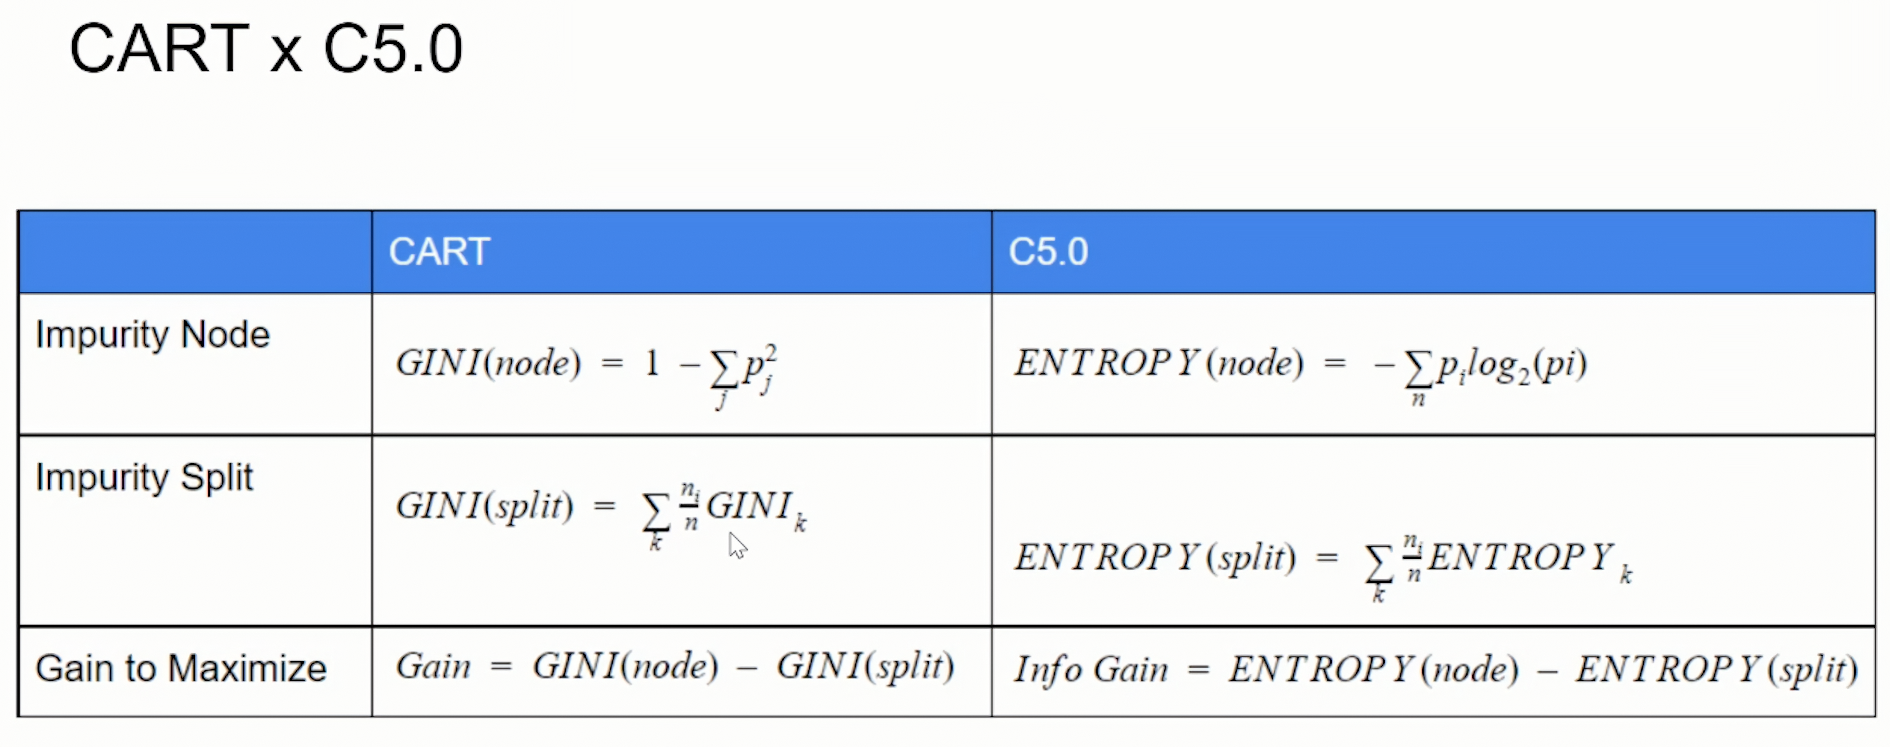


#### CHAID:

- Oldest Decision Tree Algorithm
- Can only be used with categorical independent variables (can be more than 1 category, but they need to be categorical)
    - Because of this limitation in itself it has been replaced by C5.0 and other tree algorithms.
- It tries to make the split and see what are the most significant relationships between the variables.
- The highest the Chi-squared, the lowest the correlation between the independant and dependant variable.
- It iterates through all the variables and find the ones that ae the least correlated to make the first split.
- Repeat step after a split is made.
- If at any point the split found is not statistically significant, ignore this category (merging with the previous ones.)

#### Implement SMOTE

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

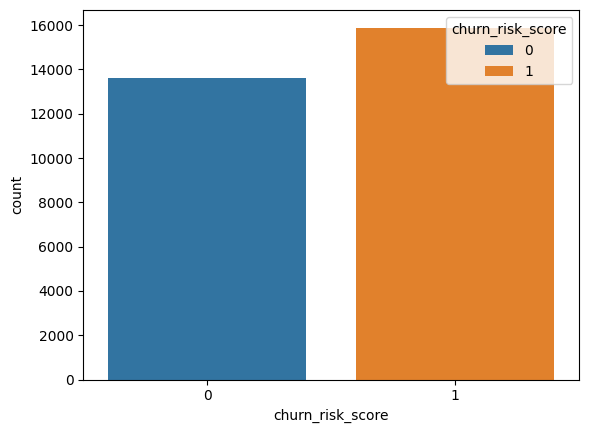

In [57]:
sns.countplot(x='churn_risk_score', data=df, hue='churn_risk_score')
plt.show()

In [58]:
def prepare_model_smote(df, class_col, cols_to_exclude):
    cols = df.select_dtypes(include=np.number).columns.tolist()
    X = df[cols]
    X = X[X.columns.difference([class_col])]
    X = X[X.columns.difference(cols_to_exclude)]
    y = df[class_col]

    global X_train, X_test, y_train, y_test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    sm = SMOTE(random_state=42)
    X_train, y_train = sm.fit_resample(X_train, y_train)

def run_model(X_train, X_test, y_train, y_test):
    global logreg

    logreg = LogisticRegression(random_state=42)
    logreg.fit(X_train, y_train)

    global y_pred
    y_pred = logreg.predict(X_test)
    logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
    print(classification_report(y_test, y_pred))
    print("The area under the curve is: %0.2f" % logit_roc_auc)


In [59]:
prepare_model_smote(df, class_col='churn_risk_score', cols_to_exclude=['customer_id', 'joining_date', 'feedback', 'year_month', 'cohort_month'])


In [60]:
run_model(X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.61      0.57      0.59      4127
           1       0.65      0.68      0.66      4720

    accuracy                           0.63      8847
   macro avg       0.63      0.63      0.63      8847
weighted avg       0.63      0.63      0.63      8847

The area under the curve is: 0.63


In [61]:
confusion_matrix(y_test, y_pred)

array([[2370, 1757],
       [1511, 3209]])

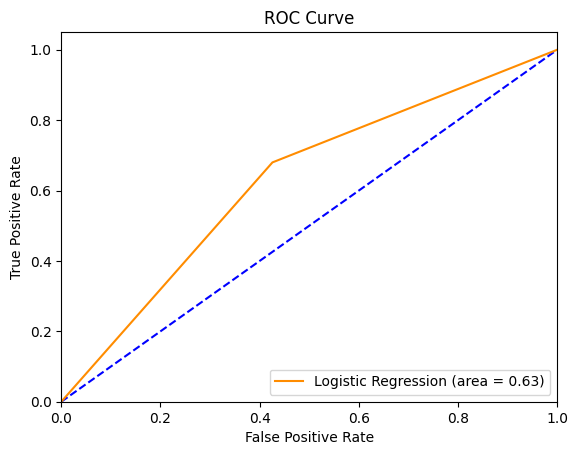

In [62]:
roc_curve (logreg,X_test,y_test)

#### Implement Decision Tree

In [63]:
def prepare_model_smote(df, class_col, cols_to_exclude):
    cols = df.select_dtypes(include=np.number).columns.tolist()
    X = df[cols]
    X = X[X.columns.difference([class_col])]
    X = X[X.columns.difference(cols_to_exclude)]
    y = df[class_col]

    global X_train, X_test, y_train, y_test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    sm = SMOTE(random_state=42, sampling_strategy=1.0)
    X_train, y_train = sm.fit_resample(X_train, y_train)

def run_model(X_train, X_test, y_train, y_test):
    global dectree

    dectree = DecisionTreeClassifier(random_state=42, criterion='gini')
    dectree.fit(X_train, y_train)

    global y_pred
    y_pred = dectree.predict(X_test)
    dectree_roc_auc = roc_auc_score(y_test, dectree.predict(X_test))
    print(classification_report(y_test, y_pred))
    print("The area under the curve is: %0.2f" % dectree_roc_auc)

In [64]:
prepare_model_smote(df, class_col='churn_risk_score', cols_to_exclude=['customer_id', 'joining_date', 'feedback', 'year_month', 'cohort_month'])
run_model(X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      4127
           1       0.83      0.83      0.83      4720

    accuracy                           0.82      8847
   macro avg       0.82      0.82      0.82      8847
weighted avg       0.82      0.82      0.82      8847

The area under the curve is: 0.82


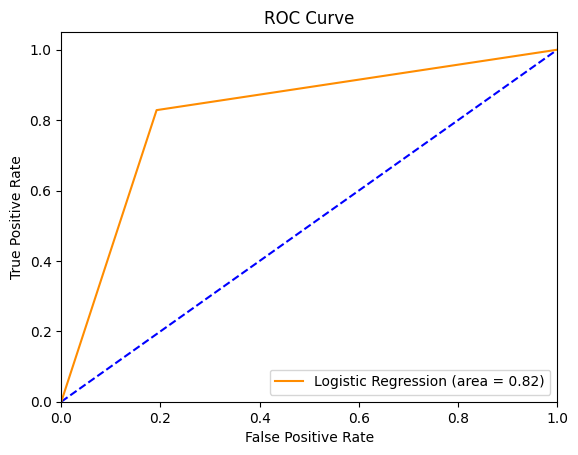

In [65]:
roc_curve (dectree,X_test,y_test)

In [66]:
def run_model(X_train, X_test, y_train, y_test):
    global dectree

    dectree = DecisionTreeClassifier(random_state=42, criterion='entropy')
    dectree.fit(X_train, y_train)

    global y_pred
    y_pred = dectree.predict(X_test)
    dectree_roc_auc = roc_auc_score(y_test, dectree.predict(X_test))
    print(classification_report(y_test, y_pred))
    print("The area under the curve is: %0.2f" % dectree_roc_auc)

In [67]:
prepare_model_smote(df, class_col='churn_risk_score', cols_to_exclude=['customer_id', 'joining_date', 'feedback', 'year_month', 'cohort_month'])
run_model(X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      4127
           1       0.83      0.83      0.83      4720

    accuracy                           0.82      8847
   macro avg       0.82      0.82      0.82      8847
weighted avg       0.82      0.82      0.82      8847

The area under the curve is: 0.82


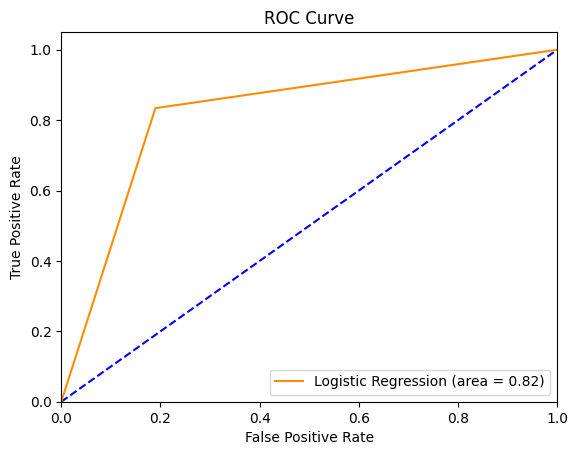

In [68]:
roc_curve (dectree,X_test,y_test)

In [69]:
confusion_matrix(y_test, y_pred)

array([[3344,  783],
       [ 784, 3936]])

In [70]:
def plot_tree(model, class_names, max_depth=None, figsize=(20, 20), fontsize=1):
    plt.figure(figsize=figsize)
    tree.plot_tree(dectree, 
                   feature_names=dectree.feature_names_in_,
                   max_depth=max_depth,
                   class_names=class_names,
                   filled=True)
    plt.show()

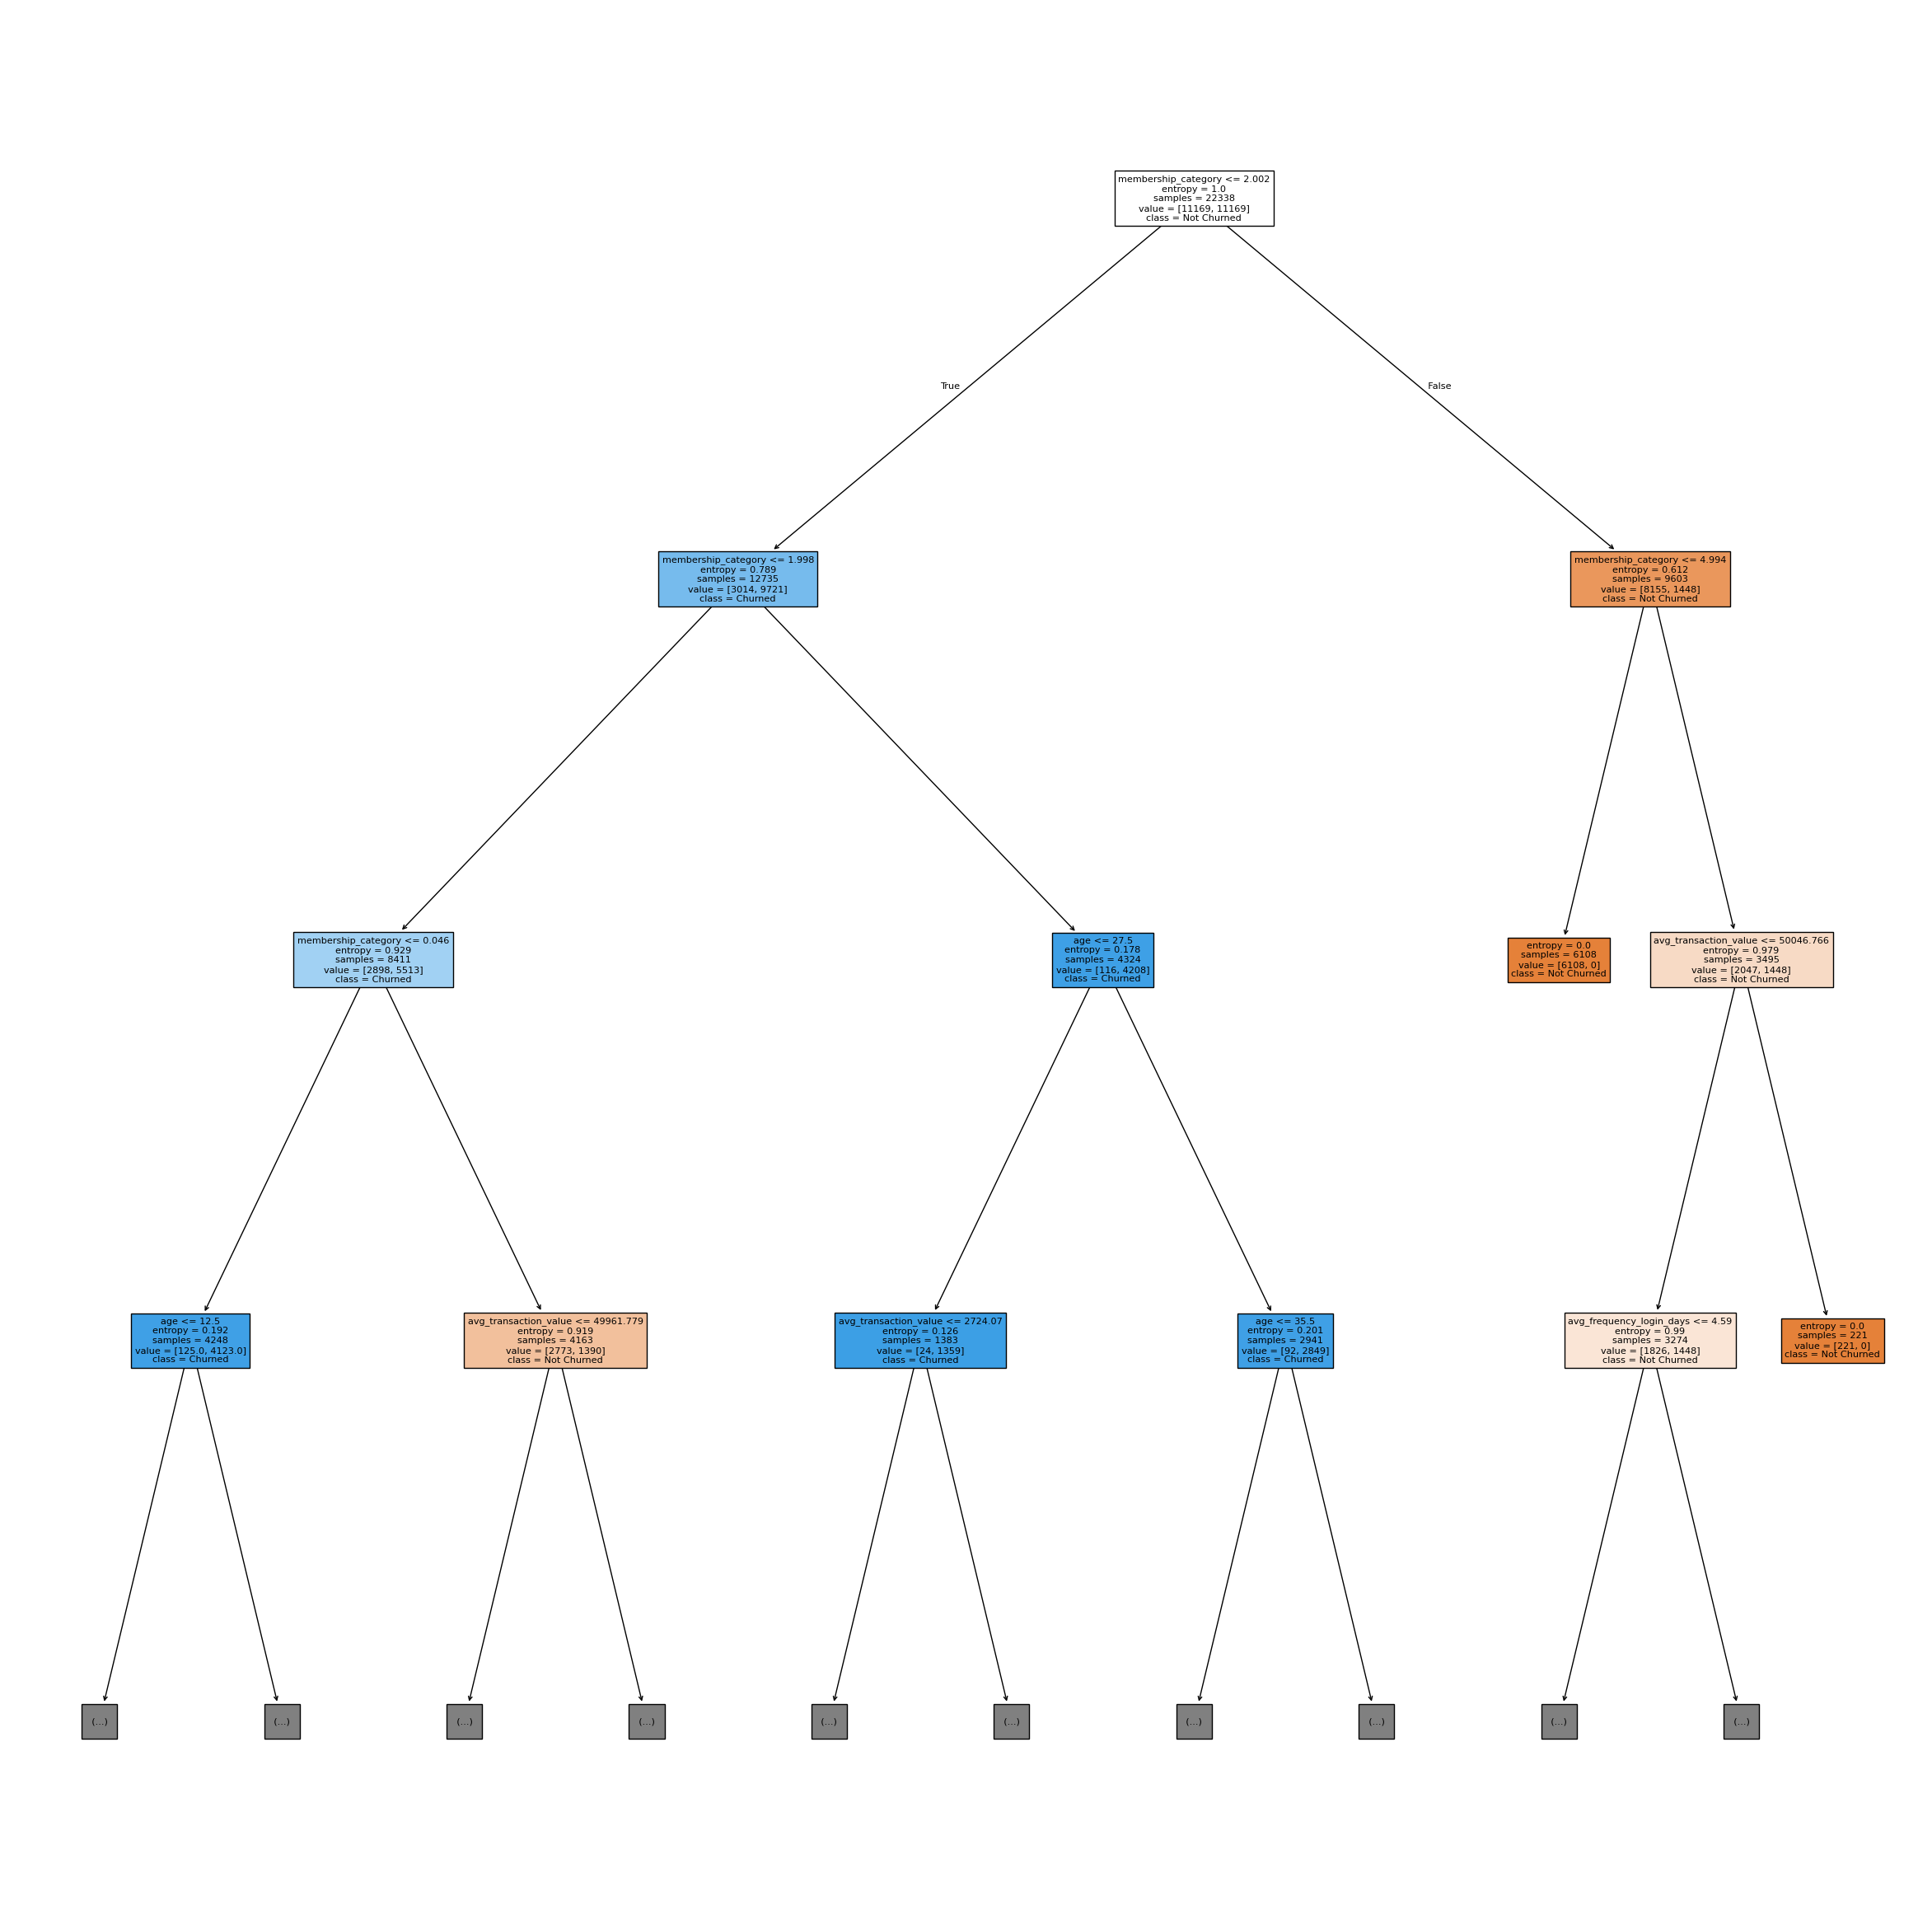

In [71]:
plot_tree(dectree, class_names=['Not Churned', 'Churned'], max_depth=3, figsize=(30, 30), fontsize=30)

In [72]:
def read_tree(model):
    n_nodes = model.tree_.node_count
    children_left = model.tree_.children_left
    children_right = model.tree_.children_right
    feature = model.tree_.feature
    feature_name = model.feature_names_in_
    threshold = model.tree_.threshold

    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaves = np.zeros(shape=n_nodes, dtype=bool)
    stack = [(0,0)]

    while len(stack) > 0:
        node_id, depth = stack.pop()
        node_depth[node_id] = depth

        is_split_node = children_left[node_id] != children_right[node_id]

        if is_split_node:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
        else:
            is_leaves[node_id] = True
    
    print(
        "The binary tree structure has {n} nodes and has "
        "the following tree structure:\n".format(n=n_nodes)
    )

    for i in range(n_nodes):
        if is_leaves[i]:
            print(
                "{space}node={node} is a leaf node.".format(
                    space=node_depth[i] * "\t", node=i
                )
            )
        else:
            print(
                "{space}node={node} is a split node: "
                "go to node {left} if {feature} <= {threshold} "
                "else to node {right}.".format(
                    space=node_depth[i] * "\t",
                    node=i,
                    left=children_left[i],
                    right=children_right[i],
                    feature=feature_name[feature[i]],
                    threshold=threshold[i],
                )
            )

In [73]:
read_tree(dectree)

The binary tree structure has 3915 nodes and has the following tree structure:

node=0 is a split node: go to node 1 if membership_category <= 2.002187490463257 else to node 2348.
	node=1 is a split node: go to node 2 if membership_category <= 1.9982929825782776 else to node 1973.
		node=2 is a split node: go to node 3 if membership_category <= 0.0456516332924366 else to node 386.
			node=3 is a split node: go to node 4 if age <= 12.5 else to node 11.
				node=4 is a split node: go to node 5 if avg_frequency_login_days <= 27.5 else to node 6.
					node=5 is a leaf node.
					node=6 is a split node: go to node 7 if referral_id <= 3995.0 else to node 10.
						node=7 is a split node: go to node 8 if complaint_status <= 1.5 else to node 9.
							node=8 is a leaf node.
							node=9 is a leaf node.
						node=10 is a leaf node.
				node=11 is a split node: go to node 12 if gender <= 0.5 else to node 231.
					node=12 is a split node: go to node 13 if days_since_last_login <= 12.5 else to 

#### Feature Importance

- A useful way to get some high-level insight into the structure of the tree is to think about feature importance.
- Decrease in node impurity weighted by the proportion of samples on a given node.


In [74]:
def plot_feature_importance(model):
    feature_importances = pd.Series(model.feature_importances_, index=model.feature_names_in_)
    feature_importances = feature_importances.sort_values(axis=0, ascending=False)
    fig, ax = plt.subplots()
    feature_importances.plot.bar()
    ax.set_title("Feature Importance")
    fig.tight_layout()

- In decision trees, feature importance is computed by looking at the `total reduction of impurity criterion` (like Gini impurity or entropy) contributed by each feature across all splits in the tree.

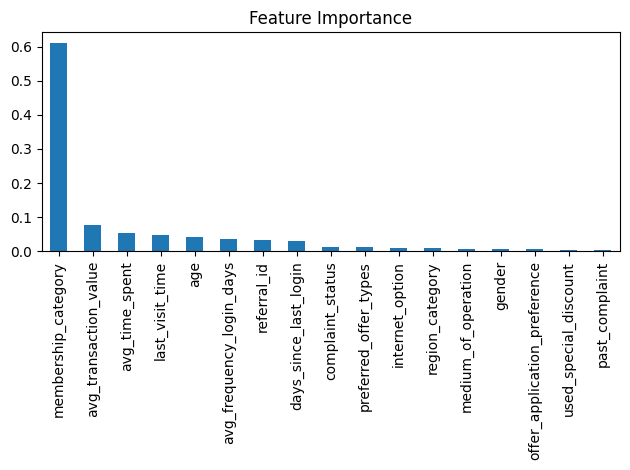

In [75]:
plot_feature_importance(dectree)

In [76]:
prepare_model_smote(df, class_col='churn_risk_score', cols_to_exclude=['customer_id', 'joining_date', 'feedback', 'year_month', 'cohort_month', 'preferred_offer_types', 'complaint_status', 'region_category', 'internet_option', 'gender', 'medium_of_operation', 'offer_application_preference', 'used_special_discount', 'past_complaint'])
run_model(X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      4127
           1       0.83      0.83      0.83      4720

    accuracy                           0.82      8847
   macro avg       0.82      0.82      0.82      8847
weighted avg       0.82      0.82      0.82      8847

The area under the curve is: 0.82


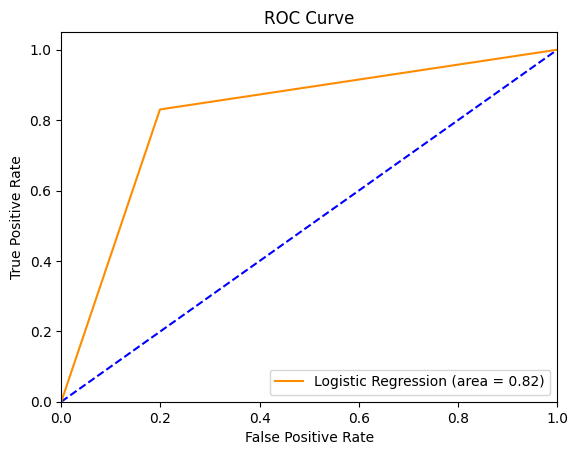

In [77]:
roc_curve (dectree,X_test,y_test)

- There is no significant changes that are observed even we have applied the feature importance.

#### Ensemble Learning

- It is combining several models in order to produce one optimal predictive model, more powerful than the original one.
- In the context of decision trees, there's a lot we can do there. Here we are applying two techniques:
    - Bagging
    - Boosting



In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import lime
import lime.lime_tabular

In [81]:
def prepare_model_smote(df,class_col,cols_to_exclude):
#Synthetic Minority Oversampling Technique. Generates new instances from existing minority cases that you supply as input. 
  from sklearn.model_selection import train_test_split
  import numpy as np
  from imblearn.over_sampling import SMOTE
  cols=df.select_dtypes(include=np.number).columns.tolist() 
  X=df[cols]
  X = X[X.columns.difference([class_col])]
  X = X[X.columns.difference(cols_to_exclude)]
  y=df[class_col]
  global X_train, X_test, y_train, y_test
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
  sm = SMOTE(random_state=0, sampling_strategy=1.0)
  X_train, y_train = sm.fit_resample(X_train, y_train) 

In [82]:
# define the random forest model
def run_model(X_train,X_test,y_train,y_test):
  from sklearn.ensemble import RandomForestClassifier
  from sklearn.metrics import roc_auc_score,classification_report
  global randomforest #Defines the random forest model as a global model that can be used outside of this function
  ##Fitting the random forest
  randomforest = RandomForestClassifier(max_depth=5)
  randomforest.fit(X_train, y_train)
  ##Predicting y values
  global y_pred #Defines the Y_Pred as a global variable that can be used outside of this function
  y_pred = randomforest.predict(X_test)
  randomforest_roc_auc = roc_auc_score(y_test, randomforest.predict(X_test))
  print(classification_report(y_test, y_pred))
  print("The area under the curve is: %0.2f"%randomforest_roc_auc)

In [83]:
prepare_model_smote(df, class_col='churn_risk_score', cols_to_exclude=['customer_id', 'joining_date', 'feedback', 'year_month', 'cohort_month'])
run_model(X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.85      0.77      0.81      4127
           1       0.81      0.88      0.84      4720

    accuracy                           0.83      8847
   macro avg       0.83      0.82      0.83      8847
weighted avg       0.83      0.83      0.83      8847

The area under the curve is: 0.82


In [84]:
randomforest.predict_proba(X_test)

array([[0.77174825, 0.22825175],
       [0.21856182, 0.78143818],
       [0.17583071, 0.82416929],
       ...,
       [0.18696062, 0.81303938],
       [0.79796142, 0.20203858],
       [0.33671813, 0.66328187]], shape=(8847, 2))

### Ada Boosting

In [85]:
# define a fucntion for class imbalance
def prepare_model_smote(df,class_col,cols_to_exclude):
#Synthetic Minority Oversampling Technique. Generates new instances from existing minority cases that you supply as input. 
  from sklearn.model_selection import train_test_split
  import numpy as np
  from imblearn.over_sampling import SMOTE
  cols=df.select_dtypes(include=np.number).columns.tolist() 
  X=df[cols]
  X = X[X.columns.difference([class_col])]
  X = X[X.columns.difference(cols_to_exclude)]
  y=df[class_col]
  global X_train, X_test, y_train, y_test
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
  sm = SMOTE(random_state=0, sampling_strategy=1.0)
  X_train, y_train = sm.fit_resample(X_train, y_train) 

In [86]:
# define an adaboost model
def run_model(X_train,X_test,y_train,y_test):
  from sklearn.ensemble import AdaBoostClassifier
  from sklearn.metrics import roc_auc_score,classification_report
  global adaboost #Defines the adaboost as a global model that can be used outside of this function
  ##Fitting the adaboost
  adaboost = AdaBoostClassifier(n_estimators = 100)
  adaboost.fit(X_train, y_train)
  ##Predicting y values
  global y_pred #Defines the Y_Pred as a global variable that can be used outside of this function
  y_pred = adaboost.predict(X_test)
  adaboost_roc_auc = roc_auc_score(y_test, adaboost.predict(X_test))
  print(classification_report(y_test, y_pred))
  print("The area under the curve is: %0.2f"%adaboost_roc_auc)

In [87]:
prepare_model_smote(df, class_col='churn_risk_score', cols_to_exclude=['customer_id', 'joining_date', 'feedback', 'year_month', 'cohort_month'])
run_model(X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.77      0.97      0.86      4127
           1       0.96      0.75      0.84      4720

    accuracy                           0.85      8847
   macro avg       0.87      0.86      0.85      8847
weighted avg       0.87      0.85      0.85      8847

The area under the curve is: 0.86


In [88]:
# this results in probabilities for the target (0 and 1) 
adaboost.predict_proba(X_test)

array([[0.66432067, 0.33567933],
       [0.3910127 , 0.6089873 ],
       [0.3910127 , 0.6089873 ],
       ...,
       [0.3910127 , 0.6089873 ],
       [0.66432067, 0.33567933],
       [0.51391539, 0.48608461]], shape=(8847, 2))

### Gradient Boosting

In [89]:
# define a fucntion for class imbalance
def prepare_model_smote(df,class_col,cols_to_exclude):
#Synthetic Minority Oversampling Technique. Generates new instances from existing minority cases that you supply as input. 
  from sklearn.model_selection import train_test_split
  import numpy as np
  from imblearn.over_sampling import SMOTE
  cols=df.select_dtypes(include=np.number).columns.tolist() 
  X=df[cols]
  X = X[X.columns.difference([class_col])]
  X = X[X.columns.difference(cols_to_exclude)]
  y=df[class_col]
  global X_train, X_test, y_train, y_test
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
  sm = SMOTE(random_state=0, sampling_strategy=1.0)
  X_train, y_train = sm.fit_resample(X_train, y_train) 

In [90]:
# define an gradient boost model
def run_model(X_train,X_test,y_train,y_test):
  from sklearn.ensemble import GradientBoostingClassifier
  from sklearn.metrics import roc_auc_score,classification_report
  global gradientboost #Defines the logistic model as a global model that can be used outside of this function
  ##Fitting the logistic regression
  gradientboost = GradientBoostingClassifier()
  gradientboost.fit(X_train, y_train)
  ##Predicting y values
  global y_pred #Defines the Y_Pred as a global variable that can be used outside of this function
  y_pred = gradientboost.predict(X_test)
  gradientboost_roc_auc = roc_auc_score(y_test, gradientboost.predict(X_test))
  print(classification_report(y_test, y_pred))
  print("The area under the curve is: %0.2f"%gradientboost_roc_auc)

In [91]:
prepare_model_smote(df, class_col='churn_risk_score', cols_to_exclude=['customer_id', 'joining_date', 'feedback', 'year_month', 'cohort_month'])
run_model(X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.77      0.95      0.85      4127
           1       0.94      0.76      0.84      4720

    accuracy                           0.85      8847
   macro avg       0.86      0.85      0.85      8847
weighted avg       0.86      0.85      0.85      8847

The area under the curve is: 0.85


### Evaluating Models

In [92]:
# define a fucntion for plotting the ROC curves
def roc_curve (model,X_test,y_test):
  import matplotlib.pyplot as plt 
  from sklearn.metrics import roc_auc_score
  from sklearn.metrics import roc_curve
  logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
  fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test))
  #Setting the graph area
  plt.figure()
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])

  #Plotting the worst line possiple
  plt.plot([0, 1], [0, 1],'b--')

  #Plotting the logistic regression we have built
  plt.plot(fpr, tpr, color='darkorange', label='Model (area = %0.2f)' % logit_roc_auc)

  #Adding labels and etc
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend(loc="lower right")
  plt.savefig('Log_ROC')
  plt.show()

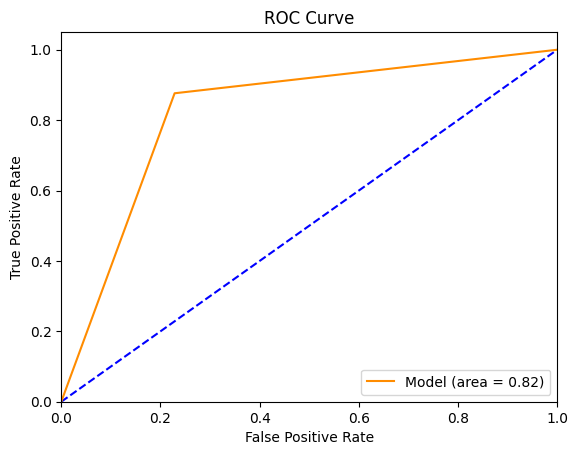

In [93]:
# ROC curve for random forest model
roc_curve (randomforest,X_test,y_test)

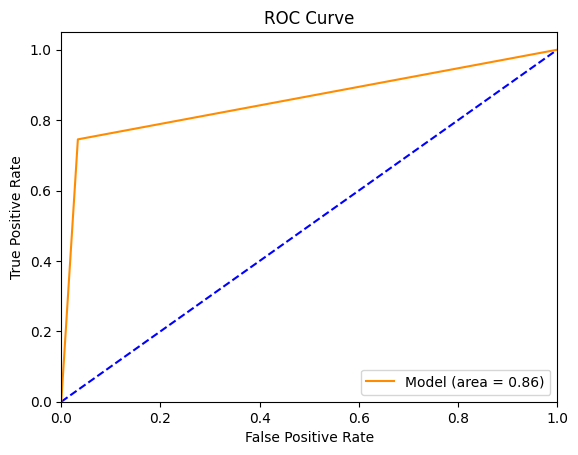

In [94]:
# ROC curve for adaboost model
roc_curve (adaboost,X_test,y_test)

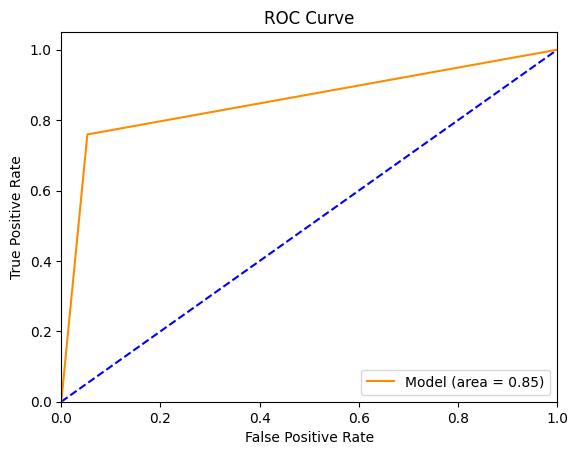

In [95]:
# ROC curve for gradient boost model
roc_curve (gradientboost,X_test,y_test)

In [96]:
# define a function for plotting the feature importances
def plot_feature_importances(model):
  feature_importances = pd.Series(model.feature_importances_, index=model.feature_names_in_)
  feature_importances = feature_importances.sort_values(axis=0, ascending=False)
  fig, ax = plt.subplots()
  feature_importances.plot.bar()
  ax.set_title("Feature importances")
  fig.tight_layout()

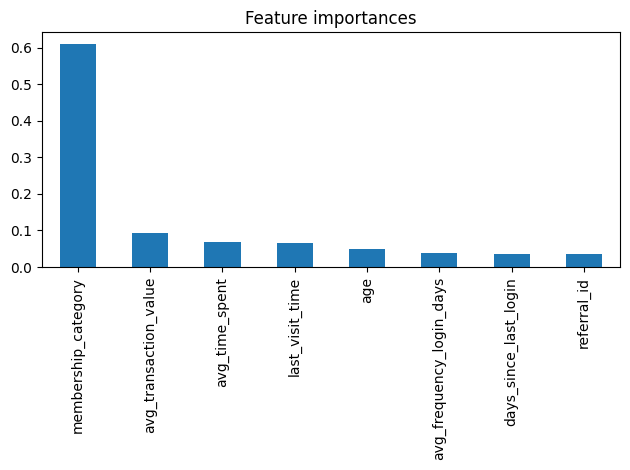

In [97]:
# feature importances for decision tree model
plot_feature_importances(dectree)

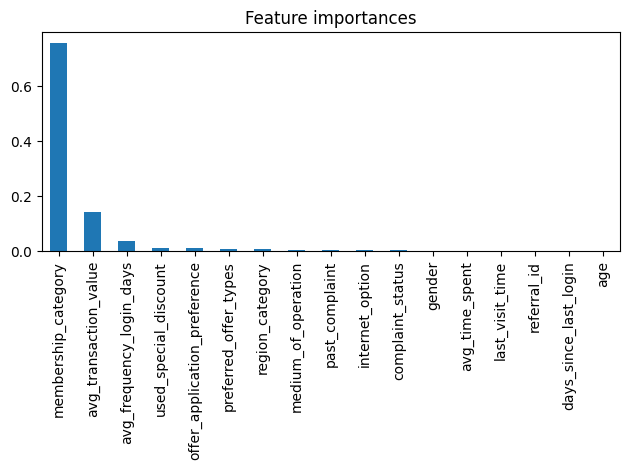

In [98]:
# feature importances for random forest model
plot_feature_importances(randomforest)

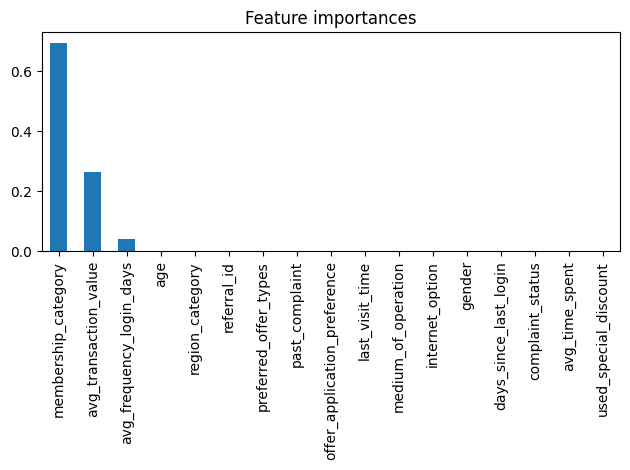

In [99]:
# feature importances for adaboost model
plot_feature_importances(adaboost)

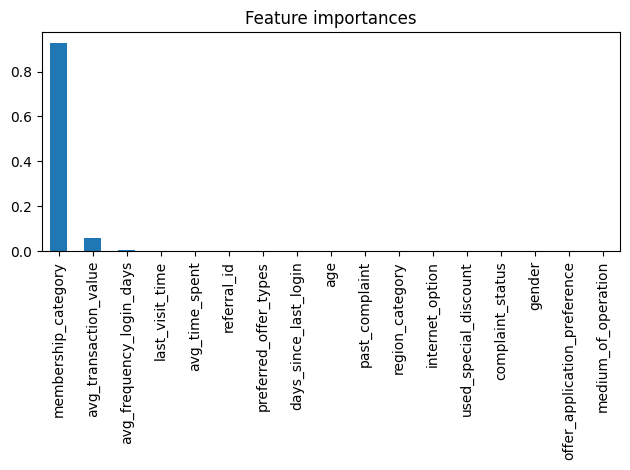

In [100]:
# feature importances for gradient boosting model
plot_feature_importances(gradientboost)

In [101]:
print("Classes:", gradientboost.classes_)
print("Prediction Probabilities:", gradientboost.predict_proba(X_test[:1]))


Classes: [0 1]
Prediction Probabilities: [[0.98967868 0.01032132]]


### LIME Evaluation

In [102]:
def lime_explanation(model, X_train, X_test, class_names, chosen_index):
    import lime
    import lime.lime_tabular
    import numpy as np

    # Ensure chosen index is within bounds
    if chosen_index >= len(X_test):
        raise IndexError("Chosen index exceeds number of samples in X_test")

    # Initialize the LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=X_train.columns.tolist(),
        class_names=class_names,
        mode='classification',
        kernel_width=5
    )

    # Select the instance to explain
    chosen_instance = X_test.iloc[chosen_index].values

    # Generate explanation
    exp = explainer.explain_instance(
        data_row=chosen_instance,
        predict_fn=lambda x: model.predict_proba(x).astype(float),
        num_features=10
    )

    # Try to display in notebook
    try:
        from IPython.display import display, HTML
        display(HTML(exp.as_html()))
    except Exception as e:
        print("Notebook display failed, saving explanation as HTML...")
        exp.save_to_file('lime_output.html')
        print(f"Explanation saved to lime_output.html\nError details: {e}")


In [103]:
# implement the lime function
lime_explanation(gradientboost,X_train,X_test,['Not Churn','Churn'],1)

In [104]:
def lime_explanation_list(model, X_train, X_test, class_names, chosen_index):
    import lime
    import lime.lime_tabular

    # Create the explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=X_train.columns.tolist(),
        class_names=class_names,
        mode='classification',
        kernel_width=5
    )

    # Get instance by position
    chosen_instance = X_test.iloc[chosen_index].values

    # Explain the instance
    exp = explainer.explain_instance(
        data_row=chosen_instance,
        predict_fn=lambda x: model.predict_proba(x).astype(float),
        num_features=10
    )

    return exp.as_list()


In [105]:
# lime implementation results in form of a list
lime_explanation_list(gradientboost,X_train,X_test,['Not Churn','Churn'],1)

[('0.00 < region_category <= 1.00', -0.01631196394399393),
 ('14184.37 < avg_transaction_value <= 27670.44', 0.016063497619781347),
 ('0.40 < past_complaint <= 1.00', -0.0097639418374082),
 ('0.00 < preferred_offer_types <= 1.00', 0.007743237849851136),
 ('0.00 < internet_option <= 1.00', 0.007062242007906174),
 ('1.00 < membership_category <= 2.00', -0.006884798367206812),
 ('used_special_discount <= 0.00', 0.00578902619430585),
 ('12502.50 < last_visit_time <= 18699.75', -0.005758741366684973),
 ('avg_time_spent <= 73.25', 0.0049861042597162085),
 ('0.00 < offer_application_preference <= 1.00', -0.003878271356662372)]

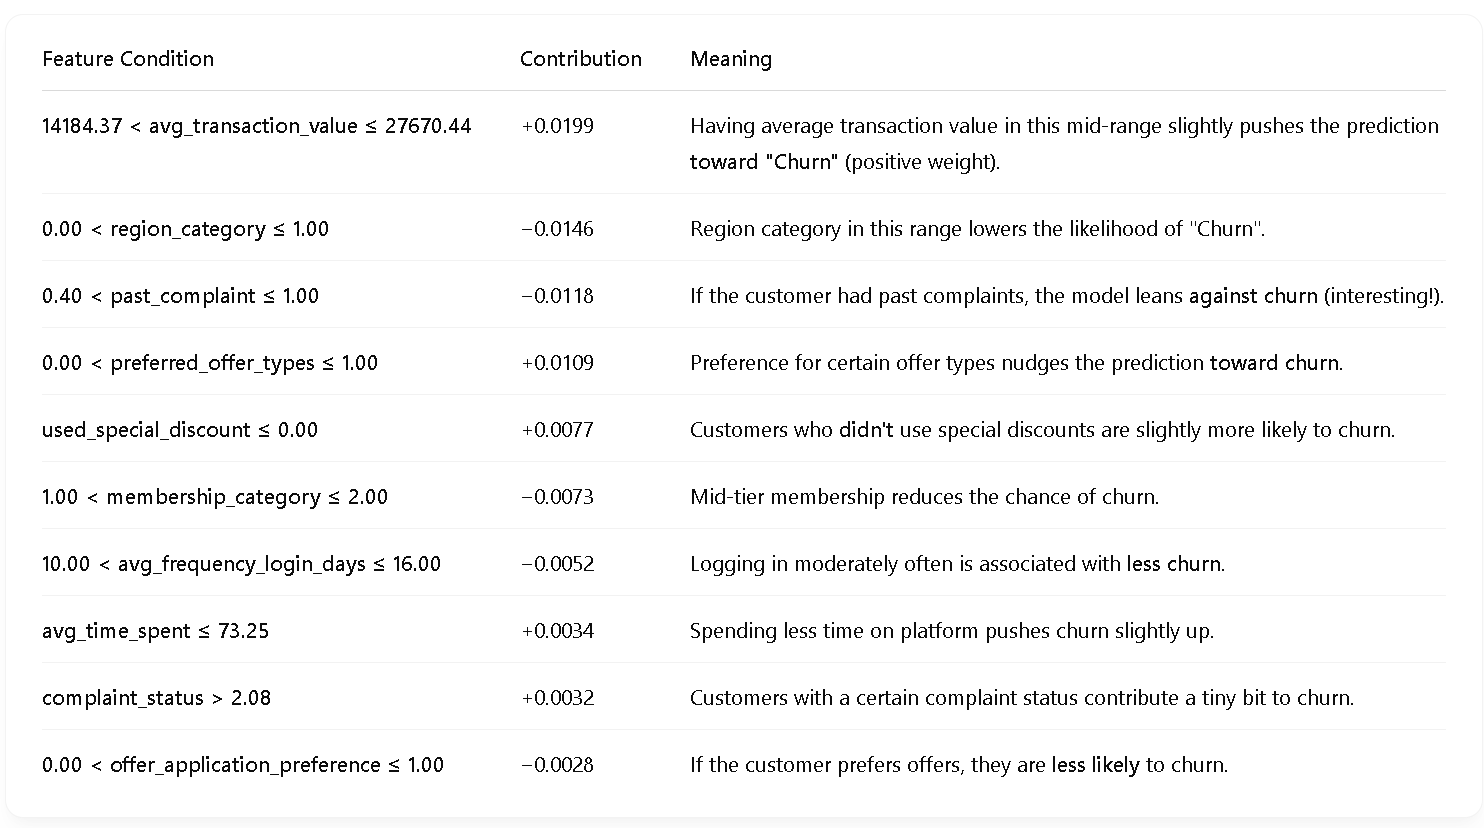

1. Positive values = Push toward "Churn"

2. Negative values = Push toward "Not Churn"

3. Most influential factor: transaction value range

4. Interesting behavior: using offers and logging in frequently reduce churn

In [107]:
# implement the lime function
lime_explanation(adaboost,X_train,X_test,['Not Churn','Churn'],1)

In [106]:
# lime implementation results in form of a list
lime_explanation_list(adaboost,X_train,X_test,['Not Churn','Churn'],1)

[('1.00 < membership_category <= 2.00', 0.08447180898377346),
 ('14184.37 < avg_transaction_value <= 27670.44', 0.037483950440559015),
 ('0.00 < region_category <= 1.00', 0.008350974570480143),
 ('gender <= 0.00', -0.006755106961956268),
 ('9582.50 < referral_id <= 9874.00', 0.00438226043518952),
 ('medium_of_operation <= 1.00', -0.003004524474770255),
 ('12502.50 < last_visit_time <= 18699.75', -0.0023767182229198183),
 ('10.00 < avg_frequency_login_days <= 16.00', -0.002374060272136432),
 ('0.00 < preferred_offer_types <= 1.00', 0.0023585940112146936),
 ('0.00 < internet_option <= 1.00', 0.0023051391822108067)]

| Feature Condition                                       | Effect        | Impact Strength | Explanation                                                                 |
|---------------------------------------------------------|---------------|------------------|------------------------------------------------------------------------------|
| 1.00 < membership_category ≤ 2.00                       | ↑ Positive    | Strong           | Mid-tier members are much more likely to be predicted positively.           |
| 14,184.37 < avg_transaction_value ≤ 27,670.44           | ↑ Positive    | Moderate         | Higher-spending users are more likely to be considered valuable.            |
| 0.00 < region_category ≤ 1.00                           | ↑ Positive    | Small            | Some regions show slightly better behavior or engagement.                   |
| gender ≤ 0.00 (Male)                                    | ↓ Negative    | Small            | Males are slightly less likely to be classified as positive.                |
| 9,582.50 < referral_id ≤ 9,874.00                       | ↑ Positive    | Very Small       | Certain referral sources tend to bring better users.                        |
| medium_of_operation ≤ 1.00 (App)                        | ↓ Negative    | Very Small       | App users are slightly less likely to get a positive prediction.            |
| 12,502.50 < last_visit_time ≤ 18,699.75                 | ↓ Negative    | Very Small       | Users visiting in this time range may be slightly less engaged.             |
| 10.00 < avg_frequency_login_days ≤ 16.00                | ↓ Negative    | Very Small       | Logging in every 10–16 days slightly lowers positivity.                     |
| 0.00 < preferred_offer_types ≤ 1.00                     | ↑ Positive    | Very Small       | Having offer preferences helps slightly.                                    |
| 0.00 < internet_option ≤ 1.00                           | ↑ Positive    | Very Small       | Internet option set is a tiny positive signal.                              |
